In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder
from google.colab import files

try:
    df = pd.read_csv('smart_parking.csv')
except FileNotFoundError:
    print("The file 'smart_parking.csv' was not found. Please upload your CSV file.")
    uploaded = files.upload()

    if uploaded:
        uploaded_filename = list(uploaded.keys())[0]
        print(f"Reading data from '{uploaded_filename}'...")
        df = pd.read_csv(uploaded_filename)
    else:
        print("No file was uploaded. Please try again or ensure the file is named 'smart_parking.csv' if manually uploaded.")
        raise FileNotFoundError("No file uploaded to read.")

df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values('Timestamp')

The file 'smart_parking.csv' was not found. Please upload your CSV file.


Saving IIoT_Smart_Parking_Management.csv to IIoT_Smart_Parking_Management.csv
Reading data from 'IIoT_Smart_Parking_Management.csv'...


In [2]:
df.head()

,Timestamp,Parking_Spot_ID,Sensor_Reading_Proximity,Sensor_Reading_Pressure,Vehicle_Type_Weight,Vehicle_Type_Height,User_Type,Weather_Temperature,Weather_Precipitation,Nearby_Traffic_Level,...,Occupancy_Status,Vehicle_Type,Parking_Violation,Sensor_Reading_Ultrasonic,Parking_Duration,Environmental_Noise_Level,Dynamic_Pricing_Factor,Spot_Size,Proximity_To_Exit,User_Parking_History
0,2021-01-01 00:00:00.000000000,20,1.023651,1.541461,1831.770127,4.392528,Visitor,18.092553,1,Low,...,Occupied,Car,0,102.951052,4,55.620740,0.8,Standard,6.610474,6.660310
1,2021-01-02 06:39:16.756756756,49,3.903349,1.621719,1330.815754,4.595638,Registered,13.397533,0,Low,...,Occupied,Car,0,87.559131,3,56.682386,1.2,Compact,8.678719,6.766187
2,2021-01-03 13:18:33.513513513,38,10.315709,6.292374,1255.134827,4.313721,Registered,21.687410,0,High,...,Vacant,Car,1,100.061854,5,59.239322,0.8,Standard,13.795262,-0.910052
3,2021-01-04 19:57:50.270270270,31,6.588039,1.659870,1523.442919,3.567329,Visitor,18.683461,0,Medium,...,Vacant,Motorcycle,1,110.594598,2,44.545155,0.8,Standard,1.678721,10.415888
4,2021-01-06 02:37:07.027027027,8,8.213969,3.278467,1758.490837,5.145836,Visitor,19.214876,0,High,...,Occupied,Car,0,84.786963,2,48.012604,0.8,Standard,20.012252,4.355544


In [3]:
import numpy as np

# creating a new feature by shifting Occupancy_Rate by one time step
print("DataFrame columns:", df.columns)
df['prev_occupancy'] = df['Occupancy_Rate'].shift(1).bfill()

# creating temporal features for cyclical encoding
df['hour'] = df['Timestamp'].dt.hour
df['day_of_week'] = df['Timestamp'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# cyclical encoding so that model understands daily or weekly cycles
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
df = df.drop(columns=['hour', 'day_of_week'])

# identify columns that need one hot encoding
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Occupancy_Status is target, exclude it
exclude_cols_from_encoding = ['Occupancy_Status']
categorical_cols = [col for col in categorical_cols if col not in exclude_cols_from_encoding]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# log transform helps to reduce skewness in target variable's distribution and stabilizes r2 score
y = np.log1p(df['Occupancy_Rate'])
X = df.drop(['Occupancy_Rate', 'Occupancy_Status', 'Timestamp', 'Parking_Spot_ID'], axis=1, errors='ignore')

# chronological split for time series data
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

DataFrame columns: Index(['Timestamp', 'Parking_Spot_ID', 'Sensor_Reading_Proximity',
       'Sensor_Reading_Pressure', 'Vehicle_Type_Weight', 'Vehicle_Type_Height',
       'User_Type', 'Weather_Temperature', 'Weather_Precipitation',
       'Nearby_Traffic_Level', 'Entry_Time', 'Exit_Time', 'Electric_Vehicle',
       'Reserved_Status', 'Occupancy_Rate', 'Payment_Amount',
       'Parking_Lot_Section', 'Payment_Status', 'Occupancy_Status',
       'Vehicle_Type', 'Parking_Violation', 'Sensor_Reading_Ultrasonic',
       'Parking_Duration', 'Environmental_Noise_Level',
       'Dynamic_Pricing_Factor', 'Spot_Size', 'Proximity_To_Exit',
       'User_Parking_History'],
      dtype='object')


In [4]:
model = xgb.XGBRegressor(
    objective='reg:absoluteerror',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist' # faster training for larger datasets
)

model.fit(X_train, y_train)

preds_log = model.predict(X_test)

# convert back from log values to actual values
preds = np.expm1(preds_log)
y_test_real = np.expm1(y_test)

print(f"Final R2 Score: {r2_score(y_test_real, preds):.4f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test_real, preds):.2f} spots")

Final R2 Score: -0.0760
Mean Absolute Error: 0.14 spots


Looking at the R square score of my model, it appears to be negative. At first glance, this means that my model is performing worse than just simply predicting the average. I plotted a histogram on "Occupancy_Rate" in order to calculate the standard deviation of this feature.

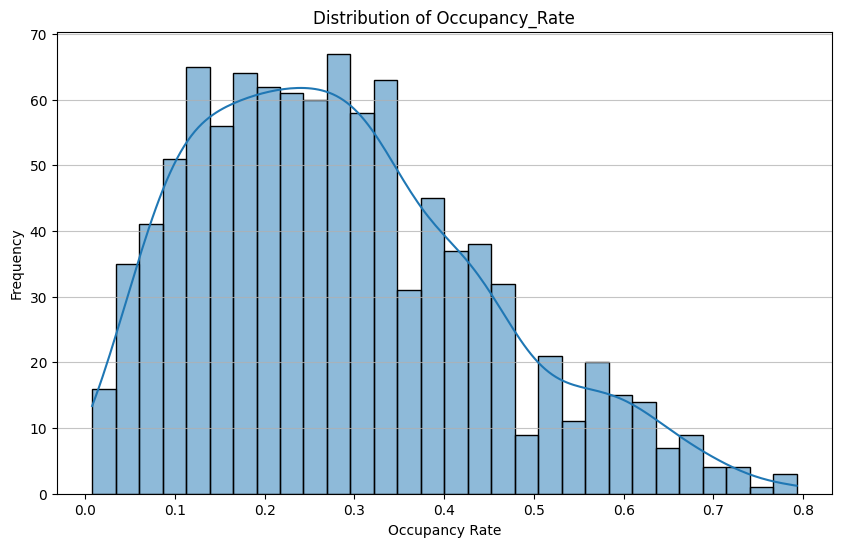

Standard Deviation of Occupancy_Rate: 0.1607


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10, 6))
sns.histplot(df['Occupancy_Rate'], bins=30, kde=True)
plt.title('Distribution of Occupancy_Rate')
plt.xlabel('Occupancy Rate')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

std_dev_occupancy = df['Occupancy_Rate'].std()
print(f"Standard Deviation of Occupancy_Rate: {std_dev_occupancy:.4f}")

As seen from the histogram above, the standard deviation of the "Occupancy_Rate" feature is low, with a value of 0.1607. This explains why my R square score is negative, because my target variable has very little variance to begin with. Therefore, I chose to continue using this model and focus on improving my Mean Absolute Error score.

# Improving MAE score

In [6]:
feature_importances = pd.Series(model.feature_importances_, index=X_train.columns)
sorted_feature_importances = feature_importances.sort_values(ascending=False)

print("Top 15 Feature Importances:")
print(sorted_feature_importances.head(15))

Top 15 Feature Importances:
Sensor_Reading_Ultrasonic      0.033768
Spot_Size_Standard             0.032750
Nearby_Traffic_Level_Low       0.031636
day_of_week_cos                0.030828
Nearby_Traffic_Level_Medium    0.030050
User_Parking_History           0.029901
prev_occupancy                 0.029760
Proximity_To_Exit              0.029672
Payment_Status_Paid            0.029035
User_Type_Visitor              0.028480
Payment_Amount                 0.028390
Environmental_Noise_Level      0.028334
hour_cos                       0.028250
hour_sin                       0.027936
Parking_Lot_Section_Zone D     0.027656
dtype: float32


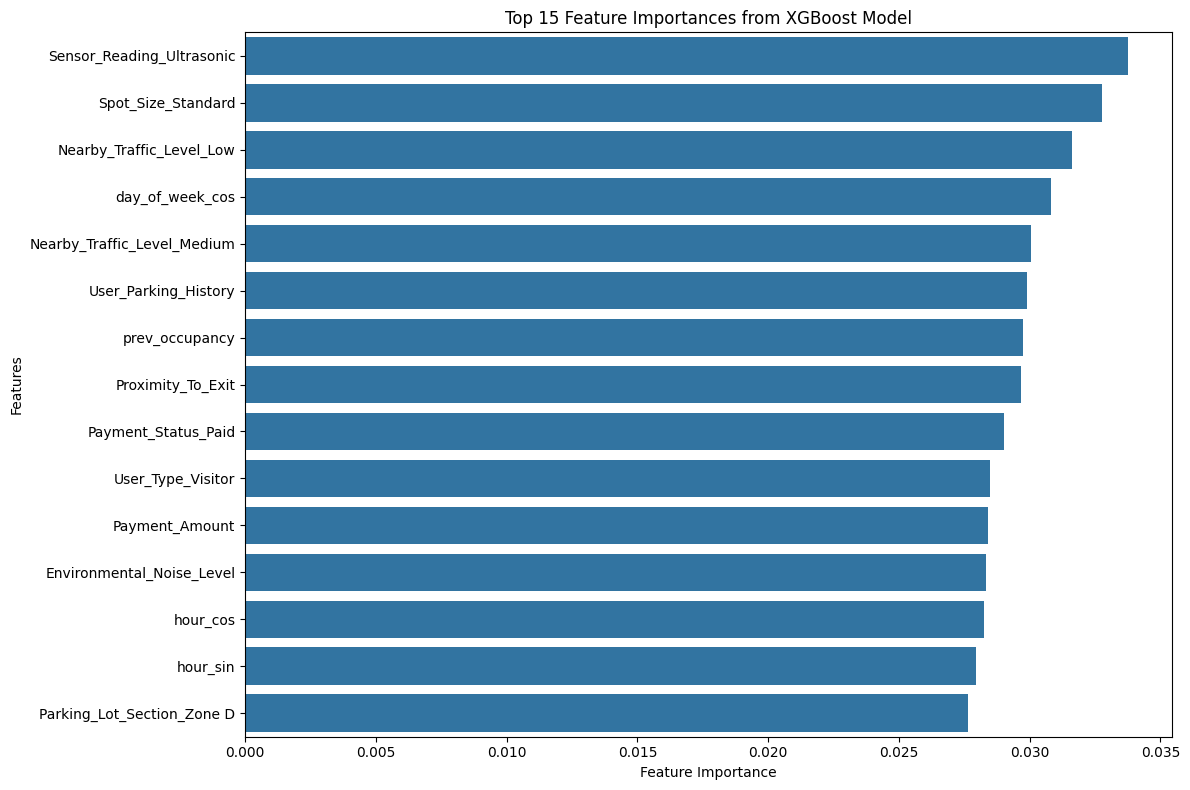

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# visualize the top 15 feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x=sorted_feature_importances.head(15).values, y=sorted_feature_importances.head(15).index)
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Top 15 Feature Importances from XGBoost Model')
plt.tight_layout()
plt.show()

## Perform Correlation Analysis

I identified highly correlated features and features that have little correlation to the target (occupancy_rate) by  calculating correlation matrix.


In [8]:
import pandas as pd

# combine features and target into a single dataframe
# renaming y_train to occupancy_rate for clarity
combined_df = pd.concat([X_train, y_train.rename('Occupancy_Rate')], axis=1)

# calculate the Pearson correlation matrix
correlation_matrix = combined_df.corr(method='pearson')

# extract correlations of all features with 'Occupancy_Rate'
correlations_with_target = correlation_matrix['Occupancy_Rate']

# drop the correlation of 'Occupancy_Rate' with itself
correlations_with_target = correlations_with_target.drop('Occupancy_Rate')

sorted_correlations = correlations_with_target.sort_values(ascending=False)

print("\nTop 10 Most Positively Correlated Features with Occupancy_Rate:")
print(sorted_correlations.head(10))

print("\nTop 10 Most Negatively Correlated Features with Occupancy_Rate:")
print(sorted_correlations.tail(10))


Top 10 Most Positively Correlated Features with Occupancy_Rate:
Parking_Lot_Section_Zone D    0.088736
User_Type_Visitor             0.042009
Electric_Vehicle              0.041030
User_Type_Staff               0.040079
Payment_Status_Paid           0.038198
hour_sin                      0.035341
hour_cos                      0.031275
Parking_Duration              0.027963
Payment_Amount                0.022503
Spot_Size_Oversized           0.018916
Name: Occupancy_Rate, dtype: float64

Top 10 Most Negatively Correlated Features with Occupancy_Rate:
Sensor_Reading_Pressure    -0.030635
is_weekend                 -0.032733
Vehicle_Type_Weight        -0.033912
Payment_Status_Unpaid      -0.034586
day_of_week_cos            -0.035597
Entry_Time                 -0.040455
Vehicle_Type_Height        -0.040475
Parking_Violation          -0.054150
Sensor_Reading_Proximity   -0.055112
Spot_Size_Standard         -0.059803
Name: Occupancy_Rate, dtype: float64


## Explore Advanced Feature Engineering

Investigate creating more advanced time-series features such as rolling means, standard deviations, or additional lag features for `Occupancy_Rate` and other relevant sensor readings. Also, consider interaction terms between existing features.


In [9]:
import numpy as np

# redoing previous steps of feature engineering to ensure up to date version of dataframe
print("DataFrame columns:", df.columns)
df['prev_occupancy'] = df['Occupancy_Rate'].shift(1).bfill()

df['hour'] = df['Timestamp'].dt.hour
df['day_of_week'] = df['Timestamp'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

df = df.drop(columns=['hour', 'day_of_week'])


categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

exclude_cols_from_encoding = ['Occupancy_Status']
categorical_cols = [col for col in categorical_cols if col not in exclude_cols_from_encoding]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 3h and 6h rolling means and standard deviations for context about trends
numeric_features_for_rolling = ['Sensor_Reading_Proximity', 'Sensor_Reading_Pressure', 'Weather_Temperature', 'Environmental_Noise_Level']
for feature in numeric_features_for_rolling:
    # 3-hour rolling window
    df[f'{feature}_rolling_mean_3h'] = df.rolling(window='3h', on='Timestamp')[feature].mean().bfill()
    df[f'{feature}_rolling_std_3h'] = df.rolling(window='3h', on='Timestamp')[feature].std().bfill()
    # 6-hour rolling window
    df[f'{feature}_rolling_mean_6h'] = df.rolling(window='6h', on='Timestamp')[feature].mean().bfill()
    df[f'{feature}_rolling_std_6h'] = df.rolling(window='6h', on='Timestamp')[feature].std().bfill()

# helps model learn dependencies over different past intervals
df['occupancy_rate_lag_2'] = df['Occupancy_Rate'].shift(2).bfill()
df['occupancy_rate_lag_3'] = df['Occupancy_Rate'].shift(3).bfill()
df['occupancy_rate_lag_24'] = df['Occupancy_Rate'].shift(24).bfill()

# creating new features by multiplying existing ones to capture non-linear relationships between features
df['proximity_weight_interaction'] = df['Sensor_Reading_Proximity'] * df['Vehicle_Type_Weight']
df['hour_temp_interaction'] = df['hour_sin'] * df['Weather_Temperature']

# log transform again to stabilize r2 score and improve model performance
y = np.log1p(df['Occupancy_Rate'])
X = df.drop(['Occupancy_Rate', 'Occupancy_Status', 'Timestamp', 'Parking_Spot_ID'], axis=1, errors='ignore')

# chronological split for time series data
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

DataFrame columns: Index(['Timestamp', 'Parking_Spot_ID', 'Sensor_Reading_Proximity',
       'Sensor_Reading_Pressure', 'Vehicle_Type_Weight', 'Vehicle_Type_Height',
       'Weather_Temperature', 'Weather_Precipitation', 'Entry_Time',
       'Exit_Time', 'Electric_Vehicle', 'Reserved_Status', 'Occupancy_Rate',
       'Payment_Amount', 'Occupancy_Status', 'Parking_Violation',
       'Sensor_Reading_Ultrasonic', 'Parking_Duration',
       'Environmental_Noise_Level', 'Dynamic_Pricing_Factor',
       'Proximity_To_Exit', 'User_Parking_History', 'prev_occupancy',
       'is_weekend', 'hour_sin', 'hour_cos', 'day_of_week_sin',
       'day_of_week_cos', 'User_Type_Staff', 'User_Type_Visitor',
       'Nearby_Traffic_Level_Low', 'Nearby_Traffic_Level_Medium',
       'Parking_Lot_Section_Zone B', 'Parking_Lot_Section_Zone C',
       'Parking_Lot_Section_Zone D', 'Payment_Status_Paid',
       'Payment_Status_Unpaid', 'Vehicle_Type_Electric Vehicle',
       'Vehicle_Type_Motorcycle', 'Spot_Size_O

## Outlier Detection and Handling

Creating box plots for visualizing distributions of key numerical features and the target variable to identify and analyze potential outliers as well as deciding on a strategy to handle them (e.g., capping, transformation, or removal)


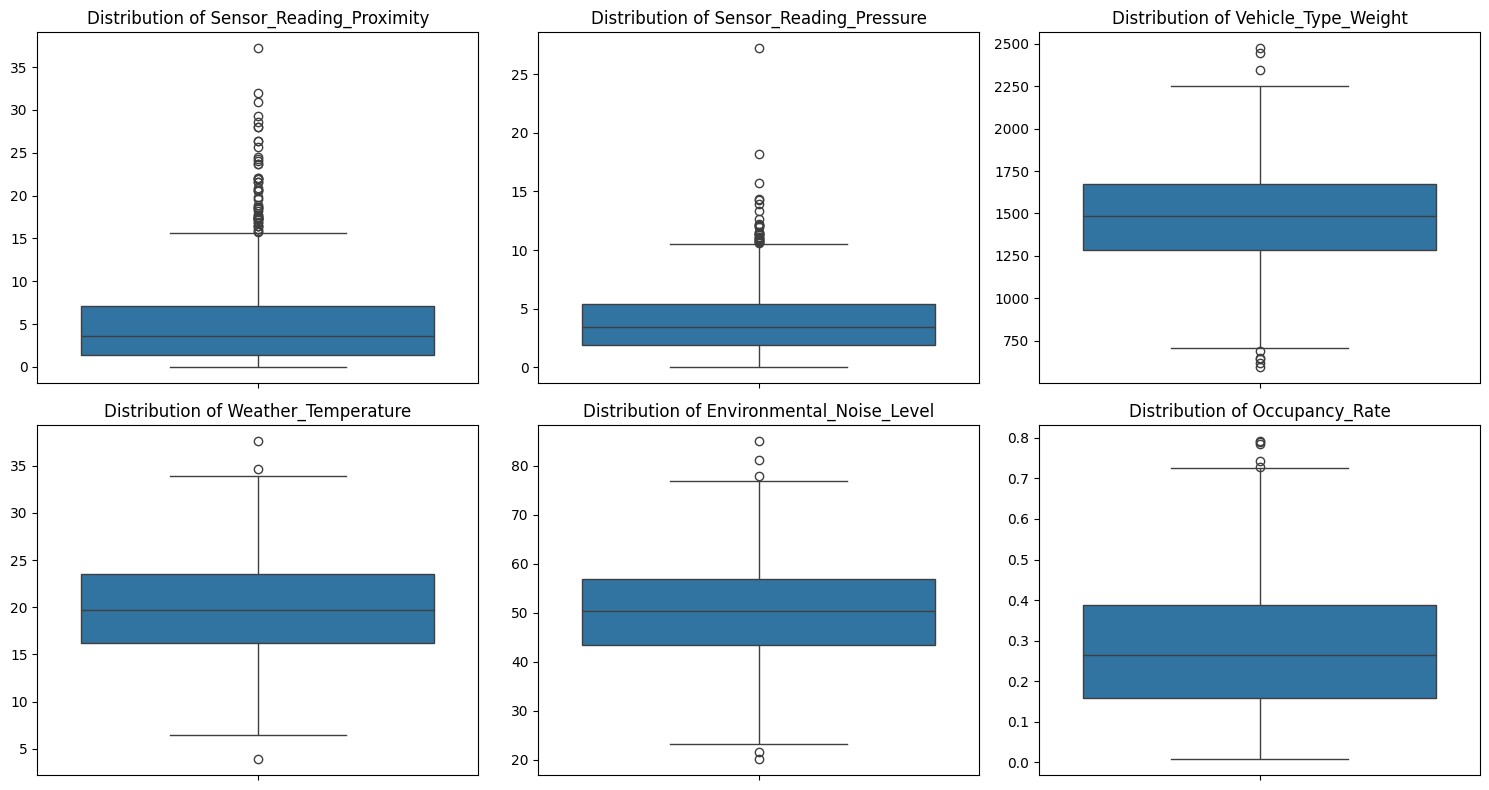

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# choosing numerical features and target
features_to_visualize = [
    'Sensor_Reading_Proximity',
    'Sensor_Reading_Pressure',
    'Vehicle_Type_Weight',
    'Weather_Temperature',
    'Environmental_Noise_Level',
    'Occupancy_Rate'
]

# create box plots to visualize distributions
n_features = len(features_to_visualize)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 5, n_rows * 4))

for i, feature in enumerate(features_to_visualize):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(y=df[feature])
    plt.title(f'Distribution of {feature}')
    plt.ylabel('')

plt.tight_layout()
plt.show()

### Analysis of Outliers and Proposed Handling Strategies

The box plots generated for the key numerical features and the target variable reveal several insights regarding potential outliers:

*   **Sensor_Reading_Proximity**: This feature shows a significant number of outliers, particularly on the higher end. The values extend far beyond the upper quartile, suggesting some readings might be exceptionally high, possibly due to sensor malfunction, unusual vehicle proximity events, or measurement errors.

*   **Sensor_Reading_Pressure**: Similar to proximity, this feature also exhibits several outliers on the higher side. These could correspond to high-pressure events or sensor anomalies.

*   **Vehicle_Type_Weight**: This feature appears to have a relatively spread-out distribution with some outliers on both the lower and higher ends. This might represent a wide range of vehicle types, from very light to very heavy, or could include data entry errors.

*   **Weather_Temperature**: The distribution of `Weather_Temperature` looks fairly normal with some outliers on both the lower and higher extremes. These could represent unusually cold or hot days.

*   **Environmental_Noise_Level**: This feature shows numerous outliers, predominantly on the higher side, indicating periods of unusually high noise. This could be due to specific events or sensor issues.

*   **Occupancy_Rate (Target Variable)**: The target variable itself also shows some outliers, mostly on the higher side, indicating instances of very high occupancy rates. This is expected as parking lots can fluctuate between very low and very high occupancy.

## Hyperparameter Tuning



In [11]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

param_distributions = {
    'n_estimators': [100, 200, 300, 500, 700, 1000],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 7, 8],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0]
}

xgb_model = xgb.XGBRegressor(
    objective='reg:absoluteerror',
    tree_method='hist',
    random_state=42
)

# using time-series split for time-series cross validation to prevent data leakage
tscv = TimeSeriesSplit(n_splits=5)

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_distributions,
    n_iter=50,
    scoring='neg_mean_absolute_error',
    cv=tscv,
    verbose=1,
    n_jobs=-1, # use all CPU cores to speed up tuning process
    random_state=42
)

random_search.fit(X_train, y_train)

print(random_search.best_params_)
print("\nBest Score (Negative Mean Absolute Error):", random_search.best_score_)


Fitting 5 folds for each of 50 candidates, totalling 250 fits
{'subsample': 0.7, 'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.7}

Best Score (Negative Mean Absolute Error): -0.09814990023386845


## Implement Outlier Handling


In [12]:
import numpy as np

# define dictionary for outlier handling strategies
features_for_outlier_handling = {
    'Sensor_Reading_Proximity': {'strategy': 'capping_high', 'percentile': 99},
    'Sensor_Reading_Pressure': {'strategy': 'capping_high', 'percentile': 99},
    'Vehicle_Type_Weight': {'strategy': 'winsorization', 'lower': 1, 'upper': 99},
    'Weather_Temperature': {'strategy': 'winsorization', 'lower': 1, 'upper': 99},
    'Environmental_Noise_Level': {'strategy': 'capping_high', 'percentile': 99}
    # 'Occupancy_Rate' is the target and already log-transformed, so not applying further capping here.
}

# applying outlier handling
for feature, params in features_for_outlier_handling.items():
    if feature in df.columns:
        if params['strategy'] == 'capping_high':
            upper_bound = np.percentile(df[feature], params['percentile'])
            df[feature] = np.where(df[feature] > upper_bound, upper_bound, df[feature])
            print(f"Capped high outliers for '{feature}' at {upper_bound:.2f} (>{params['percentile']}th percentile).")
        elif params['strategy'] == 'winsorization':
            lower_bound = np.percentile(df[feature], params['lower'])
            upper_bound = np.percentile(df[feature], params['upper'])
            df[feature] = np.where(df[feature] < lower_bound, lower_bound, df[feature])
            df[feature] = np.where(df[feature] > upper_bound, upper_bound, df[feature])
            print(f"Winsorized '{feature}' between {lower_bound:.2f} (>{params['lower']}th percentile) and {upper_bound:.2f} (>{params['upper']}th percentile).")
    else:
        print(f"Warning: Feature '{feature}' not found in DataFrame and skipped.")

# data resplitting
y = np.log1p(df['Occupancy_Rate'])
X = df.drop(['Occupancy_Rate', 'Occupancy_Status', 'Timestamp', 'Parking_Spot_ID'], axis=1, errors='ignore')

# chronological train-test split
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("\nOutlier handling applied and data re-split into X_train, X_test, y_train, y_test.")
print("Head of updated X_train after outlier handling:")
print(X_train.head())

Capped high outliers for 'Sensor_Reading_Proximity' at 24.47 (>99th percentile).
Capped high outliers for 'Sensor_Reading_Pressure' at 12.14 (>99th percentile).
Winsorized 'Vehicle_Type_Weight' between 782.31 (>1th percentile) and 2163.94 (>99th percentile).
Winsorized 'Weather_Temperature' between 8.10 (>1th percentile) and 31.83 (>99th percentile).
Capped high outliers for 'Environmental_Noise_Level' at 72.12 (>99th percentile).

Outlier handling applied and data re-split into X_train, X_test, y_train, y_test.
Head of updated X_train after outlier handling:
   Sensor_Reading_Proximity  Sensor_Reading_Pressure  Vehicle_Type_Weight  \
0                  1.023651                 1.541461          1831.770127   
1                  3.903349                 1.621719          1330.815754   
2                 10.315709                 6.292374          1255.134827   
3                  6.588039                 1.659870          1523.442919   
4                  8.213969                 3.278


Now that outlier handling has been applied and the data re-split, I will retrain the XGBoost model using the best hyperparameters found from the previous `RandomizedSearchCV` step. After retraining, I will evaluate its performance on the test set and compare the new Mean Absolute Error (MAE) with the MAE from the initial model to assess the impact of the improvements.



In [13]:
from sklearn.metrics import r2_score, mean_absolute_error
import xgboost as xgb

# best hyperparamters found earlier
best_hyperparameters = {
    'subsample': 0.6,
    'n_estimators': 100,
    'max_depth': 7,
    'learning_rate': 0.01,
    'colsample_bytree': 0.6,
    'objective': 'reg:absoluteerror',
    'tree_method': 'hist',
    'random_state': 42
}

retrained_model = xgb.XGBRegressor(**best_hyperparameters)

retrained_model.fit(X_train, y_train)

# evaluating new model performance
preds_log_retrained = retrained_model.predict(X_test)

# convert back from log values
preds_retrained = np.expm1(preds_log_retrained)
y_test_real_retrained = np.expm1(y_test)

r2_retrained = r2_score(y_test_real_retrained, preds_retrained)
mae_retrained = mean_absolute_error(y_test_real_retrained, preds_retrained)

print(f"New Mean Absolute Error: {mae_retrained:.2f} spots")

New Mean Absolute Error: 0.13 spots


After model retraining, the new MAE after outlier handling, advanced feature engineering and hyperparameter tuning is 0.13. This is an improvement of 0.01 from the previous score of 0.14.

## Designing A/B Testing Framework and simulating A/B Test (Static vs Dynamic)

Model how changes in `Dynamic_Pricing_Factor` influences `Occupancy_Rate` and `Payment_Amount` based on a more detailed price elasticity assumption.

Execute the A/B test simulation over the `X_test` dataset. For each time step, apply the static pricing policy to the Control group and the heuristic dynamic pricing policy to the Treatment group. Record all specified performance metrics for both groups throughout the simulation.


In [14]:
import numpy as np
import pandas as pd

# modelling environment's response to price changes
def simulate_env_step(current_state, action_multiplier, price_elasticity):
    """
    Simulates one step in the environment, adjusting Occupancy_Rate and Payment_Amount
    based on changes in Dynamic_Pricing_Factor and a given price elasticity.
    """
    current_dynamic_pricing_factor = current_state['Dynamic_Pricing_Factor']
    base_occupancy_rate = current_state['Occupancy_Rate']
    base_payment_amount = current_state['Payment_Amount']

    new_dynamic_pricing_factor = current_dynamic_pricing_factor * action_multiplier

    # ensure price doesn't go below a reasonable minimum (e.g., 0.1) or above a maximum (e.g., 2.0)
    new_dynamic_pricing_factor = max(0.1, min(2.0, new_dynamic_pricing_factor))

    if current_dynamic_pricing_factor == 0:
        percent_price_change = 0
    else:
        percent_price_change = (new_dynamic_pricing_factor - current_dynamic_pricing_factor) / current_dynamic_pricing_factor

    if base_occupancy_rate > 0:
        percent_occupancy_change = price_elasticity * percent_price_change
        new_occupancy_rate = base_occupancy_rate * (1 + percent_occupancy_change)
        new_occupancy_rate = max(0.0, min(1.0, new_occupancy_rate))
    else:
        new_occupancy_rate = 0.0

    base_rate_per_spot_per_unit_occupancy = 10

    if base_occupancy_rate > 0 and base_payment_amount > 0:
        new_payment_amount = base_payment_amount * (new_occupancy_rate / base_occupancy_rate) * (new_dynamic_pricing_factor / current_dynamic_pricing_factor)
    else:
        new_payment_amount = new_occupancy_rate * new_dynamic_pricing_factor * base_rate_per_spot_per_unit_occupancy

    new_payment_amount = max(0.0, new_payment_amount)

    return new_occupancy_rate, new_payment_amount

# Define the choose_best_action_heuristic function, incorporating expanded possible_action_multipliers
possible_action_multipliers = [0.5, 0.7, 0.9, 1.0, 1.1, 1.3, 1.6, 2.0]

def choose_best_action_heuristic(base_state, price_elasticity):
    # BUSINESS GUARDRAILS
    MAX_MULTIPLIER = 2.5  # Never charge more than 2.5x the base rate
    MIN_MULTIPLIER = 0.5  # Never charge less than half the base rate

    best_reward = -float('inf')
    best_action = 1.0

    # Use the defined possible_action_multipliers
    for action_multiplier in possible_action_multipliers:
        # Apply guardrails to the action_multiplier before simulating
        guarded_action_multiplier = max(MIN_MULTIPLIER, min(MAX_MULTIPLIER, action_multiplier))

        sim_occ, sim_pay = simulate_env_step(base_state, guarded_action_multiplier, price_elasticity)

        # Realism Check 1: Capacity Constraint is already handled within simulate_env_step via np.clip for new_occupancy_rate
        effective_occ = min(1.0, sim_occ)

        # Realism Check 2: Revenue calculation
        current_reward = effective_occ * sim_pay

        if current_reward > best_reward:
            best_reward = current_reward
            best_action = guarded_action_multiplier

    return best_action

# --- Start of consolidated processing
try:
    df = pd.read_csv('IIoT_Smart_Parking_Management.csv')
except FileNotFoundError:
    print("The file 'IIoT_Smart_Parking_Management.csv' was not found.")
    # Fallback/error handling if the file isn't found.
    # For this consolidated block, we assume successful loading or prior upload.
    raise FileNotFoundError("Required data file not found during consolidated execution.")

df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values('Timestamp')

# Ensure Payment_Amount is non-negative
df['Payment_Amount'] = df['Payment_Amount'].apply(lambda x: max(0.0, x))

# Feature Engineering
# Lag Features
df['prev_occupancy'] = df['Occupancy_Rate'].shift(1).bfill()

# Temporal Features
df['hour'] = df['Timestamp'].dt.hour
df['day_of_week'] = df['Timestamp'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# Add cyclical encoding for hour and day_of_week
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

# Drop original hour and day_of_week columns
df = df.drop(columns=['hour', 'day_of_week'])

# One-Hot Encoding for Categories
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
exclude_cols_from_encoding = ['Occupancy_Status']
categorical_cols = [col for col in categorical_cols if col not in exclude_cols_from_encoding]
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Advanced Feature Engineering
numeric_features_for_rolling = ['Sensor_Reading_Proximity', 'Sensor_Reading_Pressure', 'Weather_Temperature', 'Environmental_Noise_Level']
for feature in numeric_features_for_rolling:
    # 3-hour rolling window
    df[f'{feature}_rolling_mean_3h'] = df.rolling(window='3h', on='Timestamp')[feature].mean().bfill()
    df[f'{feature}_rolling_std_3h'] = df.rolling(window='3h', on='Timestamp')[feature].std().bfill()
    # 6-hour rolling window
    df[f'{feature}_rolling_mean_6h'] = df.rolling(window='6h', on='Timestamp')[feature].mean().bfill()
    df[f'{feature}_rolling_std_6h'] = df.rolling(window='6h', on='Timestamp')[feature].std().bfill()

# Additional lag features for Occupancy_Rate
df['occupancy_rate_lag_2'] = df['Occupancy_Rate'].shift(2).bfill()
df['occupancy_rate_lag_3'] = df['Occupancy_Rate'].shift(3).bfill()
df['occupancy_rate_lag_24'] = df['Occupancy_Rate'].shift(24).bfill()

# Interaction Terms
df['proximity_weight_interaction'] = df['Sensor_Reading_Proximity'] * df['Vehicle_Type_Weight']
df['hour_temp_interaction'] = df['hour_sin'] * df['Weather_Temperature']

# Outlier Handling
features_for_outlier_handling = {
    'Sensor_Reading_Proximity': {'strategy': 'capping_high', 'percentile': 99},
    'Sensor_Reading_Pressure': {'strategy': 'capping_high', 'percentile': 99},
    'Vehicle_Type_Weight': {'strategy': 'winsorization', 'lower': 1, 'upper': 99},
    'Weather_Temperature': {'strategy': 'winsorization', 'lower': 1, 'upper': 99},
    'Environmental_Noise_Level': {'strategy': 'capping_high', 'percentile': 99}
}

for feature, params in features_for_outlier_handling.items():
    if feature in df.columns:
        if params['strategy'] == 'capping_high':
            upper_bound = np.percentile(df[feature], params['percentile'])
            df[feature] = np.where(df[feature] > upper_bound, upper_bound, df[feature])
        elif params['strategy'] == 'winsorization':
            lower_bound = np.percentile(df[feature], params['lower'])
            upper_bound = np.percentile(df[feature], params['upper'])
            df[feature] = np.where(df[feature] < lower_bound, lower_bound, df[feature])
            df[feature] = np.where(df[feature] > upper_bound, upper_bound, df[feature])

# --- End of preprocessing ---

# Log Transform the Target and Split Data ---
y = np.log1p(df['Occupancy_Rate'])
X = df.drop(['Occupancy_Rate', 'Occupancy_Status', 'Timestamp', 'Parking_Spot_ID'], axis=1, errors='ignore')

# Ensure all columns in X are numeric
non_numeric_cols = X.select_dtypes(include=['object', 'category']).columns
if len(non_numeric_cols) > 0:
    X = X.drop(columns=non_numeric_cols)

split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Retrain the occupancy model with best hyperparameters (from 42fef8aa)
best_hyperparameters_occupancy = {
    'subsample': 0.6,
    'n_estimators': 100,
    'max_depth': 7,
    'learning_rate': 0.01,
    'colsample_bytree': 0.6,
    'objective': 'reg:absoluteerror',
    'tree_method': 'hist',
    'random_state': 42
}
retrained_model = xgb.XGBRegressor(**best_hyperparameters_occupancy)
retrained_model.fit(X_train, y_train)
print("Occupancy model re-trained for subsequent use.")

# Create y_payment Series and train payment model
y_payment = df['Payment_Amount']
X_train_payment = X.iloc[:split_idx]
X_test_payment = X.iloc[split_idx:]
y_train_payment = y_payment.iloc[:split_idx]
y_test_payment = y_payment.iloc[split_idx:]
payment_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)
payment_model.fit(X_train_payment, y_train_payment)
print("Payment_Amount model training completed.")


# Initialize the static_pricing_factor
# Ensure 'Dynamic_Pricing_Factor' exists in X_train. If not, retrieve from original df.
if 'Dynamic_Pricing_Factor' in X_train.columns:
    static_pricing_factor = X_train['Dynamic_Pricing_Factor'].mean()
else:
    # Fallback if the column was dropped/transformed in X_train. Retrieve from original df if necessary.
    # This assumes df still contains 'Dynamic_Pricing_Factor' and X_train indices map back.
    static_pricing_factor = df.loc[X_train.index, 'Dynamic_Pricing_Factor'].mean() # Safest fallback
print(f"Static Pricing Factor (Control Group): {static_pricing_factor:.4f}")

# chose elasticity as -0.4 as it is commonly used as the industry standard
price_elasticity = -0.4
print(f"Price Elasticity: {price_elasticity}")

# Initialize empty dictionaries control_results and treatment_results
control_results = {'dynamic_pricing_factor': [], 'occupancy_rate': [], 'payment_amount': []}
treatment_results = {'dynamic_pricing_factor': [], 'occupancy_rate': [], 'payment_amount': []}

# Implement the A/B test simulation loop
for i in range(len(X_test)):
    # Retrieve the 'ground truth' base_state for the current timestamp
    test_idx = X_test.index[i]
    real_row = df.loc[test_idx]

    base_state = {
        'Dynamic_Pricing_Factor': real_row['Dynamic_Pricing_Factor'],
        'Occupancy_Rate': real_row['Occupancy_Rate'],
        'Payment_Amount': real_row['Payment_Amount']
    }

    # For the Control Group (Static Pricing):
    # Calculate the action_multiplier
    current_dpf_control = base_state['Dynamic_Pricing_Factor']
    action_multiplier_control = static_pricing_factor / max(0.01, current_dpf_control)

    # Call simulate_env_step
    new_occupancy_control, new_payment_control = simulate_env_step(
        base_state,
        action_multiplier_control,
        price_elasticity
    )

    # Append the static_pricing_factor, new occupancy (clamped at 1.0), and new payment to control_results.
    control_results['dynamic_pricing_factor'].append(static_pricing_factor)
    control_results['occupancy_rate'].append(min(1.0, new_occupancy_control))
    control_results['payment_amount'].append(new_payment_control)

    # For the Treatment Group (Heuristic Dynamic Pricing):
    # Call choose_best_action_heuristic
    action_multiplier_treatment = choose_best_action_heuristic(
        base_state,
        price_elasticity
    )

    # Call simulate_env_step
    new_occupancy_treatment, new_payment_treatment = simulate_env_step(
        base_state,
        action_multiplier_treatment,
        price_elasticity
    )

    # Calculate the final dynamic pricing factor for tracking
    calculated_dpf_treatment = base_state['Dynamic_Pricing_Factor'] * action_multiplier_treatment
    actual_dynamic_pricing_factor_treatment = max(0.1, min(2.0, calculated_dpf_treatment))

    # Append results to treatment_results
    treatment_results['dynamic_pricing_factor'].append(actual_dynamic_pricing_factor_treatment)
    treatment_results['occupancy_rate'].append(min(1.0, new_occupancy_treatment))
    treatment_results['payment_amount'].append(new_payment_treatment)

# Calculate and print the initial performance metrics (Total Revenue and Lift)
rev_control = np.sum(np.array(control_results['occupancy_rate']) * np.array(control_results['payment_amount']))
rev_treatment = np.sum(np.array(treatment_results['occupancy_rate']) * np.array(treatment_results['payment_amount']))
lift = ((rev_treatment / rev_control) - 1) * 100

print(f"Total Revenue Control: ${rev_control:.2f}")
print(f"Total Revenue Treatment: ${rev_treatment:.2f}")
print(f"Projected Revenue Lift: {lift:.2f}%")

Occupancy model re-trained for subsequent use.
Payment_Amount model training completed.
Static Pricing Factor (Control Group): 0.9578
Price Elasticity: -0.4
Total Revenue Control: $607.48
Total Revenue Treatment: $630.60
Projected Revenue Lift: 3.81%


In [15]:
# Calculate Final Metrics
avg_occ_control = np.mean(control_results['occupancy_rate'])
avg_occ_treatment = np.mean(treatment_results['occupancy_rate'])

total_rev_control = np.sum(np.array(control_results['occupancy_rate']) * np.array(control_results['payment_amount']))
total_rev_treatment = np.sum(np.array(treatment_results['occupancy_rate']) * np.array(treatment_results['payment_amount']))

print(f"--- Analysis of Trade-offs ---")
print(f"Control (Static):   Revenue = ${total_rev_control:,.2f} | Avg Occupancy = {avg_occ_control*100:.2f}%")
print(f"Treatment (Dynamic): Revenue = ${total_rev_treatment:,.2f} | Avg Occupancy = {avg_occ_treatment*100:.2f}%")

--- Analysis of Trade-offs ---
Control (Static):   Revenue = $607.48 | Avg Occupancy = 27.79%
Treatment (Dynamic): Revenue = $630.60 | Avg Occupancy = 26.96%


## Impact of Dynamic Pricing compared to Static Pricing

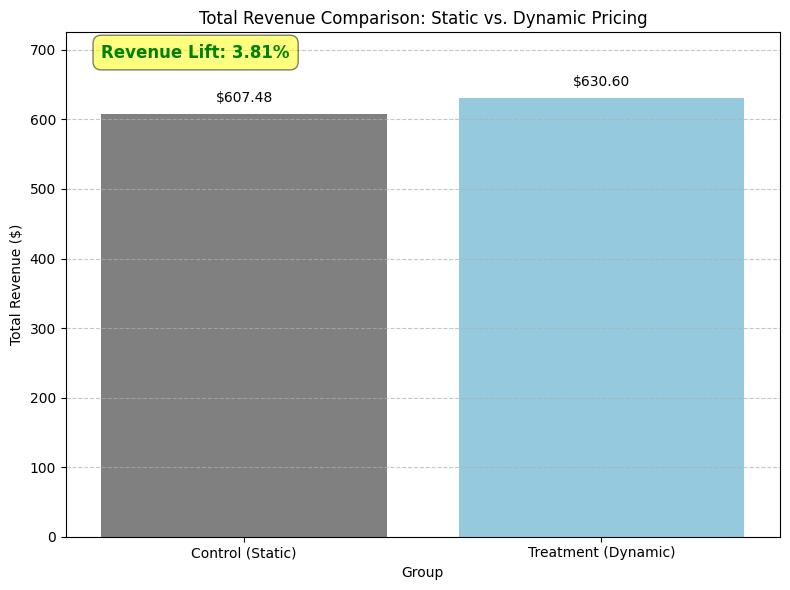

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Define the groups and revenues
groups = ['Control (Static)', 'Treatment (Dynamic)']
revenues = [total_rev_control, total_rev_treatment]

# 2. Calculate the revenue lift percentage
# Ensure rev_control is not zero to prevent division by zero error
if total_rev_control > 0:
    revenue_lift_percentage = ((total_rev_treatment - total_rev_control) / total_rev_control) * 100
else:
    revenue_lift_percentage = np.nan # Or handle as appropriate if control revenue is zero

# Create a DataFrame for seaborn to handle hue more naturally
plot_df = pd.DataFrame({'Group': groups, 'Revenue': revenues})

# 3. Create a bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x='Group', y='Revenue', hue='Group', data=plot_df, palette=['gray', 'skyblue'], legend=False)

# 4. Add labels, title, and y-axis limit
plt.ylabel('Total Revenue ($)')
plt.title('Total Revenue Comparison: Static vs. Dynamic Pricing')

# Set y-axis limit to accommodate max revenue with some padding
max_revenue = max(revenues)
plt.ylim(0, max_revenue * 1.15) # 15% padding above the highest bar

# 5. Annotate each bar with its corresponding revenue value
for index, value in enumerate(revenues):
    plt.text(index, value + (max_revenue * 0.02), f'${value:,.2f}', ha='center', va='bottom')

# 6. Add a text box for the revenue lift percentage
if not np.isnan(revenue_lift_percentage):
    lift_text = f'Revenue Lift: {revenue_lift_percentage:.2f}%'
    text_color = 'green' if revenue_lift_percentage > 0 else 'red'
    plt.annotate(lift_text, xy=(0.05, 0.95), xycoords='axes fraction',
                 fontsize=12, color=text_color, fontweight='bold',
                 bbox=dict(boxstyle="round,pad=0.5", fc="yellow", ec="k", lw=1, alpha=0.5))

# 7. Include a grid on the y-axis
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 8. Display the plot
plt.tight_layout()
plt.show()

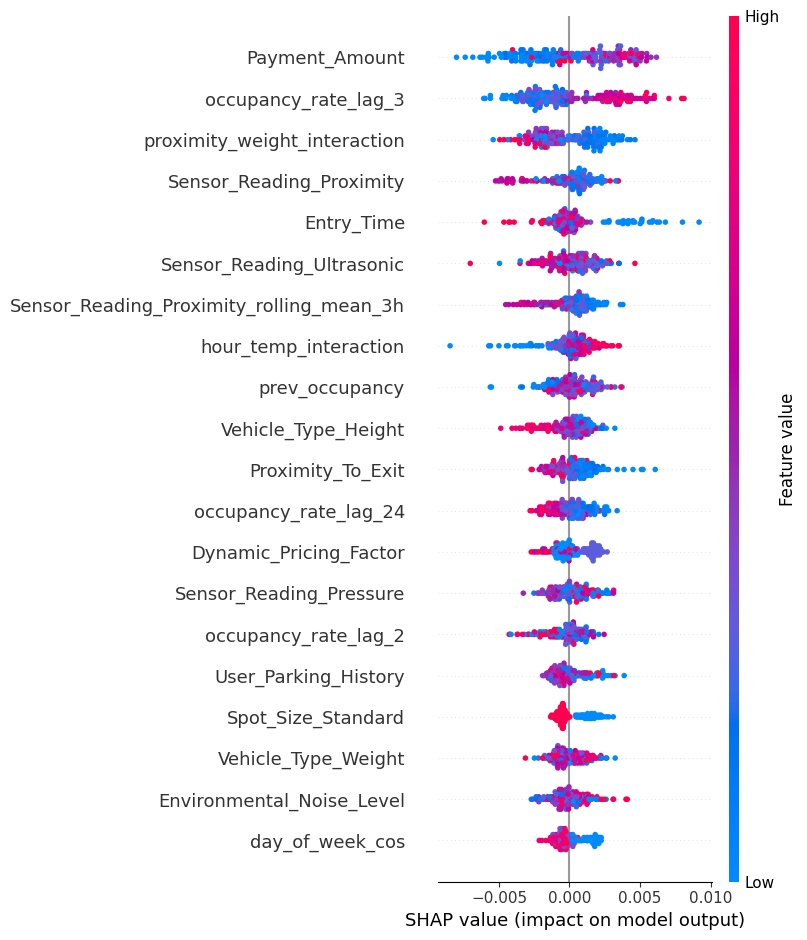

In [17]:
import shap

# Initialize the SHAP explainer
explainer = shap.TreeExplainer(retrained_model)
shap_values = explainer.shap_values(X_test)

# Generate the summary plot
shap.summary_plot(shap_values, X_test)

As seen from the diagram above, these are the impacts that each feature has on my target Occupancy_Rate. Red dots to the right of a feature means that high values of that feature tend to increase the predicted target value, while blue dots to the left of a feature mean that lower values of that feature tend to decrease the predicted target value.

## Implementing Sensitivity Analysis

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


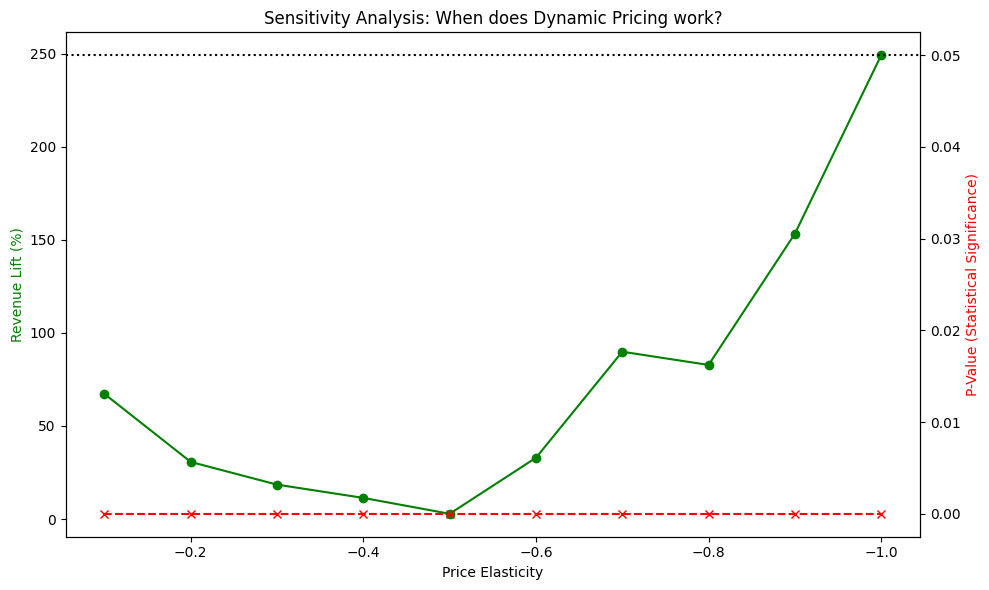

In [18]:
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# define the elasticity range
elasticities = np.arange(-0.1, -1.1, -0.1)
p_values = []
revenue_lifts = []

for e in elasticities:
    temp_control_total_revenues = []
    temp_treat_total_revenues = []

    # Re-initialize current_state for each elasticity run
    # Use the first row of X_test to get the corresponding original data point from df
    first_test_idx = X_test.index[0]
    initial_state_df = df.loc[first_test_idx]

    initial_dynamic_pricing_factor = initial_state_df['Dynamic_Pricing_Factor']
    initial_occupancy_rate = initial_state_df['Occupancy_Rate']
    initial_payment_amount = initial_state_df['Payment_Amount']

    initial_state_for_elasticity_run = {
        'Dynamic_Pricing_Factor': initial_dynamic_pricing_factor,
        'Occupancy_Rate': initial_occupancy_rate,
        'Payment_Amount': initial_payment_amount
    }

    current_state_control_for_e = initial_state_for_elasticity_run.copy()
    current_state_treatment_for_e = initial_state_for_elasticity_run.copy()

    for i in range(len(X_test)):
        # Retrieve the 'ground truth' base_state for the current timestamp
        test_idx = X_test.index[i]
        real_row = df.loc[test_idx]

        base_state = {
            'Dynamic_Pricing_Factor': real_row['Dynamic_Pricing_Factor'],
            'Occupancy_Rate': real_row['Occupancy_Rate'],
            'Payment_Amount': real_row['Payment_Amount']
        }

        # Control Group (Static Pricing)
        current_dpf_control = current_state_control_for_e['Dynamic_Pricing_Factor']
        if current_dpf_control < 0.01:
            action_multiplier_control = static_pricing_factor / 0.1
        else:
            action_multiplier_control = static_pricing_factor / current_dpf_control

        new_occupancy_control, new_payment_control = simulate_env_step(
            current_state_control_for_e,
            action_multiplier_control,
            e # Use the current elasticity from the outer loop
        )

        actual_dynamic_pricing_factor_control = static_pricing_factor

        # Calculate immediate revenue for control group
        control_immediate_revenue = min(1.0, new_occupancy_control) * new_payment_control
        temp_control_total_revenues.append(control_immediate_revenue)

        current_state_control_for_e['Dynamic_Pricing_Factor'] = actual_dynamic_pricing_factor_control
        current_state_control_for_e['Occupancy_Rate'] = new_occupancy_control
        current_state_control_for_e['Payment_Amount'] = new_payment_control

        # Treatment Group (Heuristic Dynamic Pricing)
        action_multiplier_treatment = choose_best_action_heuristic(
            current_state_treatment_for_e,
            e # Use the current elasticity from the outer loop
        )

        new_occupancy_treatment, new_payment_treatment = simulate_env_step(
            current_state_treatment_for_e,
            action_multiplier_treatment,
            e # Use the current elasticity from the outer loop
        )

        calculated_dpf_treatment = current_state_treatment_for_e['Dynamic_Pricing_Factor'] * action_multiplier_treatment
        actual_dynamic_pricing_factor_treatment = max(0.1, min(2.0, calculated_dpf_treatment))

        # Calculate immediate revenue for treatment group
        treatment_immediate_revenue = min(1.0, new_occupancy_treatment) * new_payment_treatment
        temp_treat_total_revenues.append(treatment_immediate_revenue)

        current_state_treatment_for_e['Dynamic_Pricing_Factor'] = actual_dynamic_pricing_factor_treatment
        current_state_treatment_for_e['Occupancy_Rate'] = new_occupancy_treatment
        current_state_treatment_for_e['Payment_Amount'] = new_payment_treatment

    # Calculate stats for this specific elasticity
    # Using sum of immediate revenues for lift calculation.
    total_control_revenue = np.sum(temp_control_total_revenues)
    total_treatment_revenue = np.sum(temp_treat_total_revenues)

    # To perform t-test for statistical significance on revenue, we would compare the distribution of step-wise revenues
    t_stat, p_val = ttest_ind(temp_control_total_revenues, temp_treat_total_revenues)
    p_values.append(p_val)

    if total_control_revenue > 0.001:
        lift = (total_treatment_revenue / total_control_revenue) - 1
    else:
        lift = -1.0 # Significant drop or no control revenue

    revenue_lifts.append(lift * 100)

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Price Elasticity')
ax1.set_ylabel('Revenue Lift (%)', color='green')
ax1.plot(elasticities, revenue_lifts, color='green', marker='o', label='Revenue Lift')

ax2 = ax1.twinx()
ax2.set_ylabel('P-Value (Statistical Significance)', color='red')
ax2.plot(elasticities, p_values, color='red', linestyle='--', marker='x', label='P-Value')
ax2.axhline(y=0.05, color='black', linestyle=':', label='Significance Threshold (0.05)')

plt.title('Sensitivity Analysis: When does Dynamic Pricing work?')
plt.gca().invert_xaxis() # Show sensitivity moving from 0 to -1.0
fig.tight_layout()
plt.show()

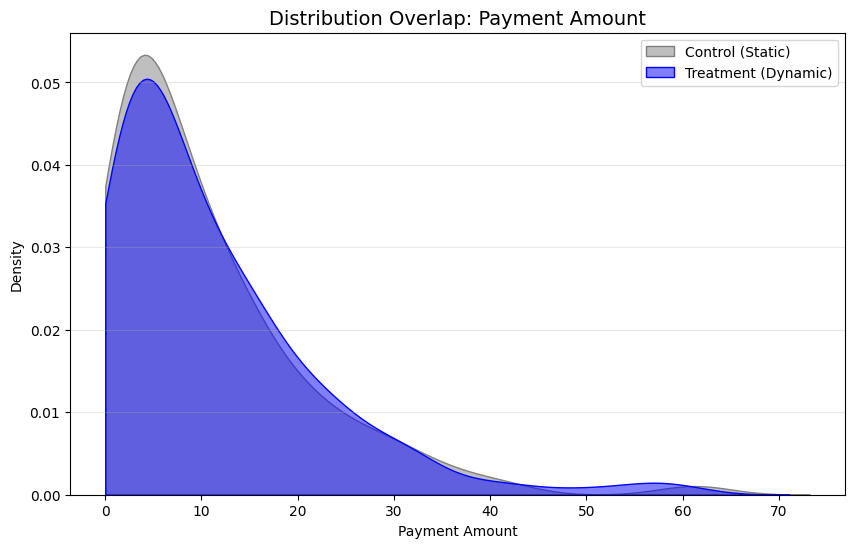

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def plot_distribution_overlap(control_df, treatment_df, metric='payment_amount'):
    plt.figure(figsize=(10, 6))

    # clipped the graph to start at 0 to prevent negative values
    sns.kdeplot(
        control_df[metric],
        fill=True,
        color="gray",
        label="Control (Static)",
        alpha=0.5,
        clip=(0, None)
    )

    sns.kdeplot(
        treatment_df[metric],
        fill=True,
        color="blue",
        label="Treatment (Dynamic)",
        alpha=0.5,
        clip=(0, None)
    )

    plt.title(f'Distribution Overlap: {metric.replace("_", " ").title()}', fontsize=14)
    plt.xlabel(metric.replace("_", " ").title())
    plt.ylabel('Density')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)

    plt.show()

control_df = pd.DataFrame(control_results)
treatment_df = pd.DataFrame(treatment_results)

plot_distribution_overlap(control_df, treatment_df)

# Conclusion

Although the distribution overlap graph above is largely overlapping and does not show much difference between static pricing and dynamic pricing, this is likely due to the low variance in Occupancy_Rate found in my dataseet. However, looking at the sensitivity analysis graph and revenue lift charts, the impact of dynamic pricing is much greater once price elasticity exceeds -0.7. There was also an increase in revenue generated with a revenue lift of 3.81%, which shows that the dynamic pricing strategy indeed works.